In [16]:
import pyspark
print(pyspark.__version__)

3.5.5


In [139]:
from pyspark.sql import SparkSession
from pyspark import SparkConf

# Step 1: Configure Spark settings
conf = SparkConf() \
    .set("spark.executor.memory", "4g")  # Set memory for executors   
    

# Step 2: Initialize SparkSession with MongoDB integration and custom config
spark = SparkSession.builder \
    .appName("MongoDBIntegration") \
    .config("spark.mongodb.read.connection.uri", "mongodb://127.0.0.1/Project.data_collection") \
    .config("spark.mongodb.write.connection.uri", "mongodb://127.0.0.1/Project.data_collection") \
    .config(conf=conf) \
    .getOrCreate()

# Now you can use the SparkSession 'spark' for your operations


In [ ]:
#Schema design of mango db
# Example of embedding customer information within sales data
{
    
    "InvoiceNo": "536392",
    "StockCode": "84879",
    "Description": "ASSORTED COLOUR BIRD ORNAMENT",
    "Quantity": 16,
    "UnitPrice": 1.69,
    "Customer": {
        "CustomerID": 13705,
        "Country": "United Kingdom"
    }
}


{'InvoiceNo': '536392',
 'StockCode': '84879',
 'Description': 'ASSORTED COLOUR BIRD ORNAMENT',
 'Quantity': 16,
 'UnitPrice': 1.69,
 'Customer': {'CustomerID': 13705, 'Country': 'United Kingdom'}}

In [36]:
from pymongo import MongoClient
import time
import requests
import pandas as pd
from io import StringIO

client =MongoClient("mongodb://localhost:27017/")
db=client['Project']
import requests

# MongoDB connection setup
client = MongoClient("mongodb://localhost:27017/")
db = client["Project"]  # Your database
collection = db["Online_Retails"]  # Your collection

# GitHub raw CSV file URL
github_url = "https://raw.githubusercontent.com/keshavsapkota3/DatasetOf/refs/heads/gh-pages/Online%20Retail.csv"  # Replace with your actual URL

# Fetch the CSV file from GitHub
response = requests.get(github_url)
response.raise_for_status()  # Ensure the request was successful

# Read the CSV data into a pandas DataFrame
csv_data = StringIO(response.text)
df = pd.read_csv(csv_data)

# Convert DataFrame to dictionary records
data_dict = df.to_dict(orient="records")

# Insert data into MongoDB
if data_dict:
    collection.insert_many(data_dict)
    print(f"✅ Successfully inserted {len(data_dict)} records into '{db.name}.{collection.name}'")
else:
    print("⚠️ No data found to insert.")


✅ Successfully inserted 541909 records into 'Project.Online_Retails'


DataFrame from MongoDB 

In [43]:


# Connect to the MongoDB server
client = MongoClient('localhost', 27017)

# Access the database and collection
db = client['Project']
collection = db['Online_Retails']

# Fetch all documents from the collection
cursor = collection.find()

# Convert cursor to DataFrame
df1 = pd.DataFrame(list(cursor))

# Drop the '_id' column if it exists
if '_id' in df1.columns:
    df1.drop('_id', axis=1, inplace=True)

# Display the first few rows of the DataFrame
print(df1.head())


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [44]:
# lets so the asic of data processing 
df1.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [46]:
df1.shape

(2167636, 8)

In [48]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2167636 entries, 0 to 2167635
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   InvoiceNo    object 
 1   StockCode    object 
 2   Description  object 
 3   Quantity     int64  
 4   InvoiceDate  object 
 5   UnitPrice    float64
 6   CustomerID   float64
 7   Country      object 
dtypes: float64(2), int64(1), object(5)
memory usage: 132.3+ MB


In [49]:
df1.count

<bound method DataFrame.count of         InvoiceNo StockCode                          Description  Quantity  \
0          536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1          536365     71053                  WHITE METAL LANTERN         6   
2          536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3          536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4          536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...           ...       ...                                  ...       ...   
2167631    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
2167632    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
2167633    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
2167634    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
2167635    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

             InvoiceDate  Unit

In [54]:
import numpy as np
missingvalue=df1.isnull().sum()
print(missingvalue)

InvoiceNo           0
StockCode           0
Description      5816
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     540320
Country             0
dtype: int64


In [56]:
df1=df1.dropna()

In [59]:
dropcolumn = ['CustomerID']
df1 = df1.drop(columns=dropcolumn, axis=1)
df1.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,United Kingdom


In [60]:
df1.count()

InvoiceNo      1627316
StockCode      1627316
Description    1627316
Quantity       1627316
InvoiceDate    1627316
UnitPrice      1627316
Country        1627316
dtype: int64

In [63]:

print('Duplicate Data:', df1.duplicated().sum(),'\n')
# There is no duplicate value.
df1= df1.drop_duplicates()
print('Duplicate Data:', df1.duplicated().sum(),'\n')

Duplicate Data: 0 

Duplicate Data: 0 



In [100]:
 #Convert 'InvoiceDate' to datetime
df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'], format='%m/%d/%Y %H:%M')

# Extract Year and Month
df1['YearMonth'] = df1['InvoiceDate'].dt.to_period('M')
print(df1[['InvoiceDate', 'YearMonth']].head())

# Calculate Total Sale for each row
df1['TotalSale'] = df1['Quantity'] * df1['UnitPrice']
print(df1[['Quantity', 'UnitPrice', 'TotalSale']].head())

# Aggregate monthly sales total
monthly_sales = df1.groupby('YearMonth')['TotalSale'].sum().reset_index()
print(monthly_sales)

          InvoiceDate YearMonth
0 2010-12-01 08:26:00   2010-12
1 2010-12-01 08:26:00   2010-12
2 2010-12-01 08:26:00   2010-12
3 2010-12-01 08:26:00   2010-12
4 2010-12-01 08:26:00   2010-12
   Quantity  UnitPrice  TotalSale
0         6       2.55      15.30
1         6       3.39      20.34
2         8       2.75      22.00
3         6       3.39      20.34
4         6       3.39      20.34
   YearMonth    TotalSale
0    2010-12   552372.860
1    2011-01   473731.900
2    2011-02   435534.070
3    2011-03   578576.210
4    2011-04   425222.671
5    2011-05   647011.670
6    2011-06   606862.520
7    2011-07   573112.321
8    2011-08   615078.090
9    2011-09   929356.232
10   2011-10   973306.380
11   2011-11  1126815.070
12   2011-12   341539.430


In [78]:
# Aggregate sales by country
sales_by_country = df1.groupby('Country')['TotalSale'].sum().reset_index()
print(sales_by_country)


                 Country    TotalSale
0              Australia   137009.770
1                Austria    10154.320
2                Bahrain      548.400
3                Belgium    40910.960
4                 Brazil     1143.600
5                 Canada     3666.380
6        Channel Islands    20076.390
7                 Cyprus    12858.760
8         Czech Republic      707.720
9                Denmark    18768.140
10                  EIRE   250001.780
11    European Community     1291.750
12               Finland    22326.740
13                France   196626.050
14               Germany   221509.470
15                Greece     4710.520
16               Iceland     4310.000
17                Israel     6988.400
18                 Italy    16890.510
19                 Japan    35340.620
20               Lebanon     1693.880
21             Lithuania     1661.060
22                 Malta     2505.470
23           Netherlands   284661.540
24                Norway    35163.460
25          

In [74]:


# 1. Verify DataFrames
print("Monthly Sales columns:", monthly_sales.columns.tolist())
print("Sales by Country columns:", sales_by_country.columns.tolist())

# 2. Connect to MongoDB
client = MongoClient('mongodb://localhost:27017/')
db = client['Project']
collection = db['sales_data']

def prepare_data(df):
    """Convert all datetime-like columns to strings"""
    for col in df.columns:
        # Handle Period objects (which don't work with select_dtypes)
        if hasattr(df[col], 'dt') and hasattr(df[col].dt, 'strftime'):
            df[col] = df[col].astype(str)
        # Handle numpy datetime64
        elif np.issubdtype(df[col].dtype, np.datetime64):
            df[col] = df[col].astype(str)
    return df

# 2. Prepare DataFrames
monthly_sales = prepare_data(monthly_sales.copy())
sales_by_country = prepare_data(sales_by_country.copy())

# 3. Combine and insert records
all_records = []
for df in [monthly_sales, sales_by_country]:
    if not df.empty:
        all_records.extend(df.to_dict('records'))

if all_records:
    collection.insert_many(all_records)
    print(f"Successfully inserted {len(all_records)} records")
else:
    print("Warning: No records to insert")

Monthly Sales columns: ['YearMonth', 'TotalSale']
Sales by Country columns: ['Country', 'TotalSale']
Successfully inserted 50 records


In [ ]:
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()

In [125]:
# Step 1: Convert Pandas DataFrame to PySpark DataFrame
df1_spark = spark.createDataFrame(df1)

# Step 2: Check the schema of the PySpark DataFrame to ensure it has the correct structure
df1_spark.printSchema()

# Step 3: Register the PySpark DataFrame as a temporary SQL view
df1_spark.createOrReplaceTempView("sales_view")

# Step 4: Run the SQL query to calculate monthly sales totals
monthly_sales_query = """
SELECT
    YEAR(CAST(InvoiceDate AS DATE)) AS Year,
    MONTH(CAST(InvoiceDate AS DATE)) AS Month,
    SUM(TotalSale) AS MonthlyTotal
FROM
    sales_view
GROUP BY
    YEAR(CAST(InvoiceDate AS DATE)),
    MONTH(CAST(InvoiceDate AS DATE))
ORDER BY
    Year DESC,
    Month DESC
"""

# Step 5: Execute the SQL query and show the results
monthly_sales = spark.sql(monthly_sales_query)
monthly_sales.show()


root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- Country: string (nullable = true)
 |-- YearMonth: struct (nullable = true)
 |-- TotalSale: double (nullable = true)

+----+-----+------------------+
|Year|Month|      MonthlyTotal|
+----+-----+------------------+
|2011|   12| 341539.4300000026|
|2011|   11|1126815.0699999628|
|2011|   10| 973306.3799999919|
|2011|    9| 929356.2319999955|
|2011|    8| 615078.0900000093|
|2011|    7| 573112.3210000116|
|2011|    6| 606862.5200000101|
|2011|    5| 647011.6700000024|
|2011|    4| 425222.6710000125|
|2011|    3| 578576.2100000154|
|2011|    2| 435534.0700000151|
|2011|    1|473731.90000001626|
|2010|   12| 552372.8600000186|
+----+-----+------------------+



In [127]:
##Optimizing the data frame
# Cache the DataFrame if it's reused multiple times
df1_spark.cache()


DataFrame[InvoiceNo: string, StockCode: string, Description: string, Quantity: bigint, InvoiceDate: timestamp, UnitPrice: double, Country: string, YearMonth: struct<>, TotalSale: double]

In [128]:
# Repartition DataFrame based on 'Country' column
df_sales_repartitioned = df1_spark.repartition("Country")


In [154]:
# Access the 'Project' database
db = client['Project']

In [155]:
# Access the 'Online_Retails' collection
collection = db['Online_Retails']


In [161]:
# Create an ascending index on 'InvoiceDate'
index_name = collection.create_index([('InvoiceDate', 1)])

# Output the name of the created index
print(f"Index created: {index_name}")


Index created: InvoiceDate_1


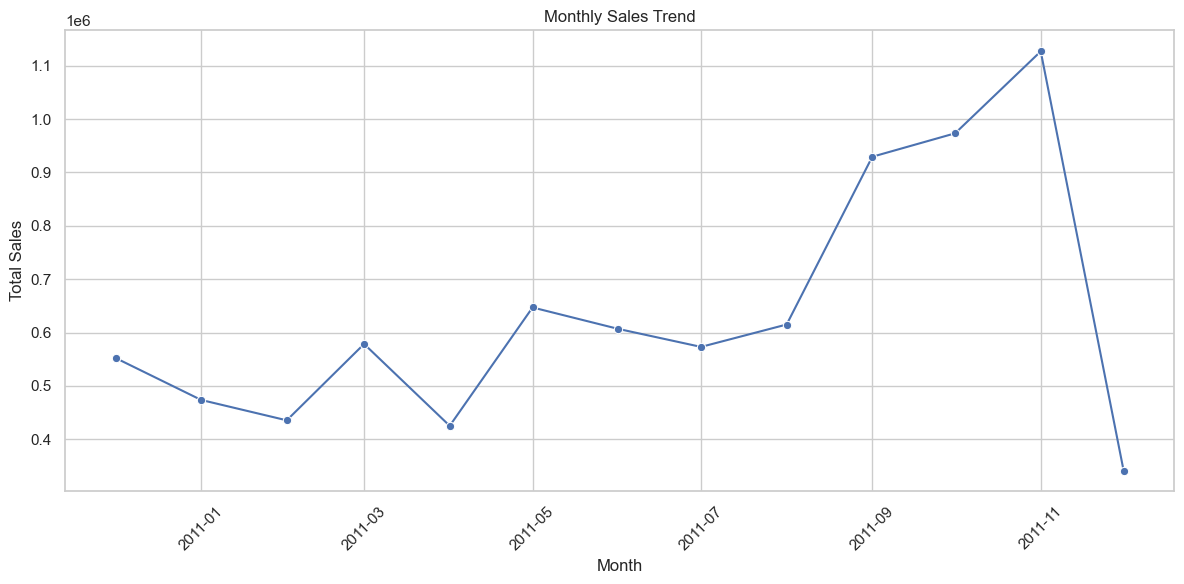

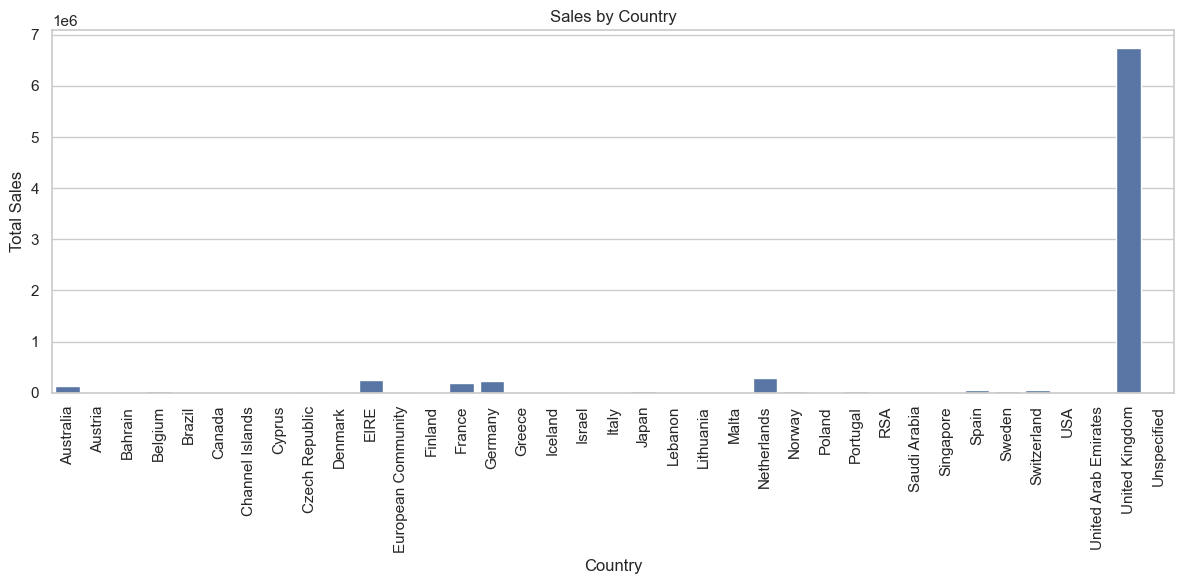

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()
# Set the style
sns.set(style="whitegrid")

# Plot Monthly Sales Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='TotalSale', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Sales by Country
plt.figure(figsize=(12, 6))
sns.barplot(data=sales_by_country, x='Country', y='TotalSale')
plt.title('Sales by Country')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Sales by Country


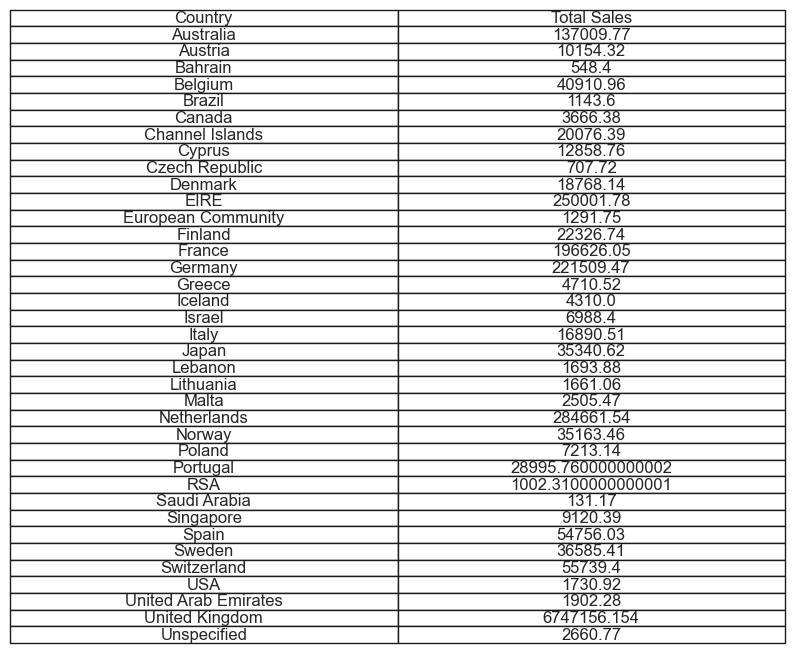

In [92]:
# Fetch data from MongoDB
sales_data = collection.find()
df_sales = pd.DataFrame(list(sales_data))

# Aggregate sales by country
sales_by_country = df_sales.groupby('Country')['TotalSale'].sum().reset_index()

# Display the sales by country in a table
import matplotlib.pyplot as plt
print('Sales by Country')
plt.figure(figsize=(10, 6))
plt.axis('off')  # Hide axes
plt.table(cellText=sales_by_country.values,
          colLabels=['Country', 'Total Sales'],
          cellLoc='center',
          loc='center')

plt.show()

In [101]:
sales_by_country_sorted = sales_by_country.sort_values(by='TotalSale', ascending=False).reset_index(drop=True)


In [108]:
top_selling_countries_from_third = sales_by_country_sorted.iloc[1:]


In [106]:
# Select top 10 countries
top_10_countries = top_selling_countries_from_third = sales_by_country_sorted.iloc[1:].head(10)


C:\Users\geone\AppData\Local\Temp\ipykernel_16236\2688802798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_countries, x='Country', y='TotalSale', palette='viridis')


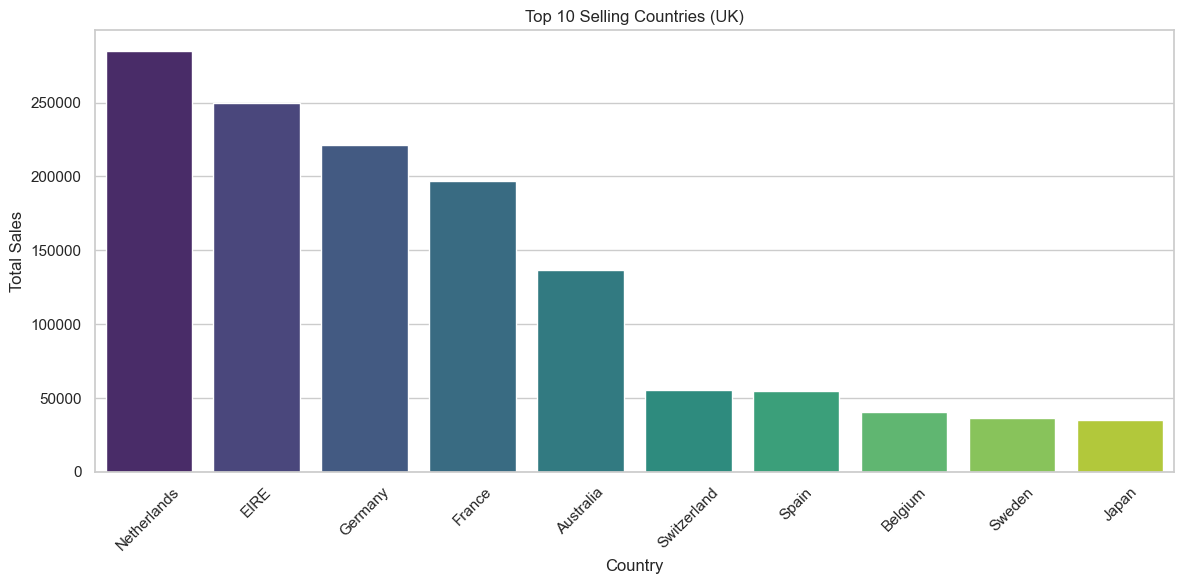

In [112]:
# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_countries, x='Country', y='TotalSale', palette='viridis')
plt.title('Top 10 Selling Countries (UK)')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()